# Pipeline 5 — Omnipose + Swin Transformer (Windows / VS Code)

This notebook is the Windows/VS-Code-ready conversion of the original Colab pipeline.

It keeps the original research workflow:

1. Load the Zagajewski TIFF dataset and parse metadata.
2. Robust fluorescence TIFF normalization.
3. Omnipose bacterial instance segmentation.
4. Cell/cell-patch extraction.
5. Group-aware train/validation/test splitting.
6. Swin-Tiny phenotype classification.
7. Accuracy, Precision, Recall, F1, ROC-AUC and confusion matrix.
8. Swin Grad-CAM-style explainability.
9. Save the trained model and experiment metadata.

## Local-first configuration

The notebook is configured initially for a **small laptop smoke test**:
- `MAX_IMAGES_FOR_BUILD = 2`
- `BATCH_SIZE = 2`
- `NUM_WORKERS = 0`
- `EPOCHS = 2`

After the complete pipeline works, increase these values gradually.

**Important:** Set `DATA_ROOT` to the local folder that contains your TIFF files. No Google Drive or Colab paths are used.


## 0. Installation strategy

Install the packages once in the project's virtual environment using the accompanying `requirements.txt`.

Omnipose is used for segmentation through its `cellpose_omni` implementation. Standalone `cellpose`, `segment-anything`, and `captum` are not required by this pipeline.


In [1]:
# Verify the local Python environment.
import sys
import importlib.util

print("Python:", sys.version)

required = [
    "torch", "torchvision", "timm", "albumentations",
    "cv2", "tifffile", "sklearn", "seaborn", "cellpose_omni"
]

for pkg in required:
    print(f"{pkg:20s}:", "OK" if importlib.util.find_spec(pkg) else "MISSING")

try:
    import torch
    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("CUDA device:", torch.cuda.get_device_name(0))
    else:
        print("Using CPU")
except Exception as e:
    print("PyTorch check failed:", repr(e))


Python: 3.12.5 (tags/v3.12.5:ff3bc82, Aug  6 2024, 20:45:27) [MSC v.1940 64 bit (AMD64)]
torch               : OK
torchvision         : OK
timm                : OK
albumentations      : OK
cv2                 : OK
tifffile            : OK
sklearn             : OK
seaborn             : OK
cellpose_omni       : OK
PyTorch: 2.14.0+cpu
CUDA available: False
Using CPU


## 1. Imports and reproducibility

In [2]:
import os, glob, re, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import tifffile
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    confusion_matrix, roc_curve, classification_report
)

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PyTorch: 2.14.0+cpu
CUDA: False
Device: CPU


## 2. Local dataset configuration and metadata

The Colab Google Drive mounting/extraction code has been removed.

Point `DATA_ROOT` directly to the local `Data` directory containing the `.tif` files.

Examples:
- `Path(r"D:\Zagajewski_Project\data\Data")`
- `Path(r"C:\Users\YourName\Documents\Zagajewski_Project\data\Data")`


In [5]:
# =========================
# LOCAL DATASET CONFIGURATION
# =========================

from pathlib import Path

# CHANGE THIS to your local folder containing the TIFF files.
DATA_ROOT = Path(r"../Zagajewski_Data/Data/MG1655/All_images")

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {DATA_ROOT}\n"
        "Please edit DATA_ROOT to the folder containing your .tif files."
    )

data_root = str(DATA_ROOT)

print("Resolved Data Root:", data_root)

# Expected filename pattern:
# Date_ExpID_SpeciesID_Conc_Proj_Stage_Acq_Treatment_PosID.tif


Resolved Data Root: ..\Zagajewski_Data\Data\MG1655\All_images


In [6]:
def parse_filename(filepath):
    fname = os.path.basename(filepath)
    stem = Path(fname).stem
    parts = stem.split("_")

    if len(parts) < 9:
        return None

    return {
        "path": filepath,
        "filename": fname,
        "date": parts[0],
        "exp_id": parts[1],
        "species": parts[2],
        "conc": parts[3],
        "proj": parts[4],
        "stage": parts[5],
        "acq": parts[6],
        "treatment": parts[7],
        "pos": "_".join(parts[8:])  # preserve any additional underscores
    }

all_tifs = sorted(glob.glob(os.path.join(data_root, "**", "*.tif"), recursive=True))
parsed_meta = [parse_filename(p) for p in all_tifs]
parsed_meta = [x for x in parsed_meta if x is not None]

df_meta = pd.DataFrame(parsed_meta)

if df_meta.empty:
    raise RuntimeError("No valid TIFF files were parsed.")

print(f"TIFF files found: {len(all_tifs)}")
print(f"Valid metadata rows: {len(df_meta)}")
display(df_meta.head())

print("\nTreatment values:")
display(df_meta["treatment"].value_counts(dropna=False))

TIFF files found: 1568
Valid metadata rows: 1568


,path,filename,date,exp_id,species,conc,proj,stage,acq,treatment,pos
0,..\Zagajewski_Data\Data\MG1655\All_images\CIP+...,200818_1_MG1655_NA_AMR_combined_1_CIP+ETOH_pos...,200818,1,MG1655,NA,AMR,combined,1,CIP+ETOH,posXY0
1,..\Zagajewski_Data\Data\MG1655\All_images\CIP+...,200818_1_MG1655_NA_AMR_combined_1_CIP+ETOH_pos...,200818,1,MG1655,NA,AMR,combined,1,CIP+ETOH,posXY1
2,..\Zagajewski_Data\Data\MG1655\All_images\CIP+...,200818_1_MG1655_NA_AMR_combined_1_CIP+ETOH_pos...,200818,1,MG1655,NA,AMR,combined,1,CIP+ETOH,posXY10
3,..\Zagajewski_Data\Data\MG1655\All_images\CIP+...,200818_1_MG1655_NA_AMR_combined_1_CIP+ETOH_pos...,200818,1,MG1655,NA,AMR,combined,1,CIP+ETOH,posXY11
4,..\Zagajewski_Data\Data\MG1655\All_images\CIP+...,200818_1_MG1655_NA_AMR_combined_1_CIP+ETOH_pos...,200818,1,MG1655,NA,AMR,combined,1,CIP+ETOH,posXY12



Treatment values:


treatment
WT+ETOH        455
COAMOX+ETOH    350
CIP+ETOH       285
RIF+ETOH       279
GENT+ETOH      199
Name: count, dtype: int64

## 3. TIFF loading and fluorescence normalization

In [7]:
def read_tiff_rgb2(path):
    arr = tifffile.imread(path)
    arr = np.asarray(arr)

    # Convert CHW -> HWC when the first dimension clearly looks like channels.
    if arr.ndim == 3 and arr.shape[0] <= 4 and arr.shape[-1] > 4:
        arr = np.moveaxis(arr, 0, -1)

    if arr.ndim == 2:
        arr = arr[..., None]

    if arr.ndim != 3:
        raise ValueError(f"Unsupported TIFF shape {arr.shape} for {path}")

    if arr.shape[-1] < 2:
        raise ValueError(f"Need at least 2 channels (Nile Red + DAPI): {arr.shape}")

    return arr[..., :2]


def percentile_normalize_channel(x, low=1, high=99):
    x = np.asarray(x, dtype=np.float32)
    lo, hi = np.percentile(x, [low, high])

    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)

    return np.clip((x - lo) / (hi - lo), 0, 1)


def make_rgb_fluorescence(path):
    """
    Load a fluorescence TIFF and create:
      1. raw_rg: two-channel fluorescence image
      2. rgb: normalized 3-channel image for visualization/model input
    """

    img = tifffile.imread(path)

    # Convert to numpy array
    img = np.asarray(img)

    print("Loaded TIFF:")
    print("  shape:", img.shape)
    print("  dtype:", img.dtype)

    # Handle common TIFF layouts
    if img.ndim == 2:
        # Single-channel image
        g = img
        r = img

    elif img.ndim == 3:
        # Possible layouts:
        #   H x W x C
        #   C x H x W
        if img.shape[-1] >= 2:
            # H x W x C
            r = img[..., 0]
            g = img[..., 1]

        elif img.shape[0] >= 2:
            # C x H x W
            r = img[0]
            g = img[1]

        else:
            raise ValueError(
                f"Unsupported 3D TIFF shape: {img.shape}"
            )

    else:
        raise ValueError(
            f"Unsupported TIFF dimensions: {img.ndim}, shape={img.shape}"
        )

    # Convert to float32
    r = r.astype(np.float32)
    g = g.astype(np.float32)

    # Robust percentile normalization
    def normalize_channel(x):
        lo, hi = np.percentile(x, (1, 99))

        if hi <= lo:
            return np.zeros_like(x, dtype=np.float32)

        x = (x - lo) / (hi - lo)
        return np.clip(x, 0, 1).astype(np.float32)

    r_norm = normalize_channel(r)
    g_norm = normalize_channel(g)

    # Two-channel representation
    raw_rg = np.stack([r, g], axis=-1)

    # RGB representation:
    # R = fluorescence channel 1
    # G = fluorescence channel 2
    # B = zero channel
    rgb = np.stack(
        [r_norm, g_norm, np.zeros_like(r_norm)],
        axis=-1
    ).astype(np.float32)

    return raw_rg, rgb

Loaded TIFF:
  shape: (3, 684, 420)
  dtype: uint16
Raw RG shape: (3, 684, 2) dtype: float32
Normalized RGB shape: (3, 684, 3) range: 0.0 1.0


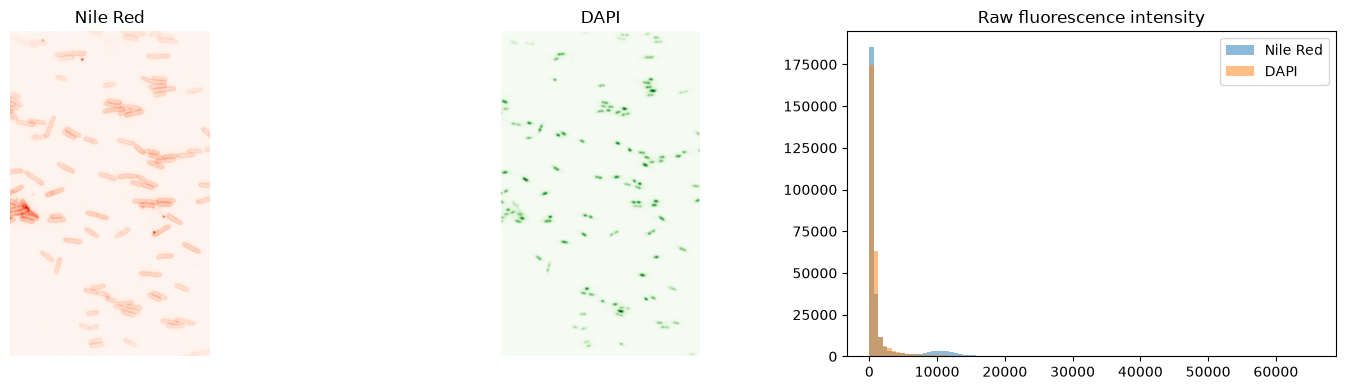

In [8]:
sample_path = df_meta.iloc[0]["path"]
sample_rg, sample_rgb = make_rgb_fluorescence(sample_path)

print("Raw RG shape:", sample_rg.shape, "dtype:", sample_rg.dtype)
print("Normalized RGB shape:", sample_rgb.shape, "range:", sample_rgb.min(), sample_rgb.max())
def plot_channel_distributions(path):
    rg = read_tiff_rgb2(path)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(rg[..., 0], cmap="Reds")
    axes[0].set_title("Nile Red")

    axes[1].imshow(rg[..., 1], cmap="Greens")
    axes[1].set_title("DAPI")

    axes[2].hist(rg[..., 0].ravel(), bins=100, alpha=0.5, label="Nile Red")
    axes[2].hist(rg[..., 1].ravel(), bins=100, alpha=0.5, label="DAPI")
    axes[2].set_title("Raw fluorescence intensity")
    axes[2].legend()

    for ax in axes[:2]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_channel_distributions(sample_path)

## 4. Exploratory data analysis

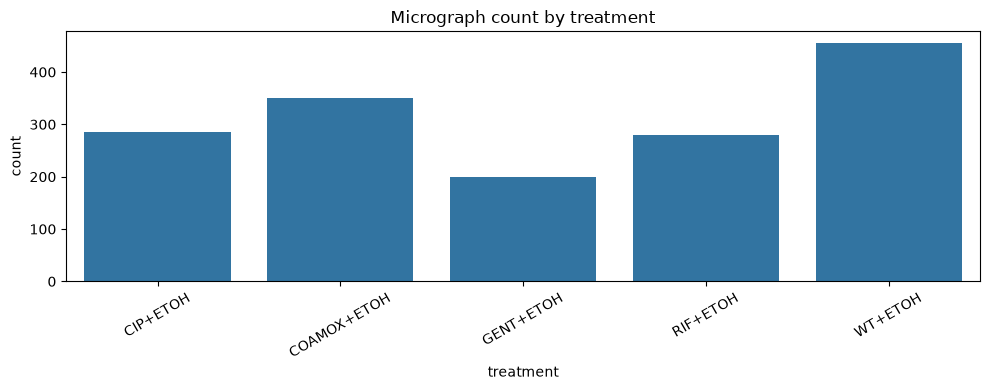

,path,height,width,pixels,red_p99,green_p99
count,50,50.0,50.0,50.0,50.000000,50.000000
unique,50,NaN,NaN,NaN,NaN,NaN
top,..\Zagajewski_Data\Data\MG1655\All_images\CIP+...,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,684.0,420.0,287280.0,22077.804000,12746.015200
std,NaN,0.0,0.0,0.0,9694.156077,8466.810221
min,NaN,684.0,420.0,287280.0,3172.210000,1389.210000
25%,NaN,684.0,420.0,287280.0,16321.867500,5408.182500
50%,NaN,684.0,420.0,287280.0,20957.235000,10756.130000
75%,NaN,684.0,420.0,287280.0,28742.972500,19600.787500


In [9]:
# Basic treatment distribution
plt.figure(figsize=(10, 4))
sns.countplot(data=df_meta, x="treatment")
plt.title("Micrograph count by treatment")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Image dimensions and channel summary on a limited sample.
rows = []
for p in df_meta["path"].head(min(50, len(df_meta))):
    rg = read_tiff_rgb2(p)
    rows.append({
        "path": p,
        "height": rg.shape[0],
        "width": rg.shape[1],
        "pixels": rg.shape[0] * rg.shape[1],
        "red_p99": np.percentile(rg[..., 0], 99),
        "green_p99": np.percentile(rg[..., 1], 99),
    })

display(pd.DataFrame(rows).describe(include="all"))

## 5. Omnipose segmentation

In [10]:
from omnipose import core
from cellpose_omni import models

USE_GPU = False
# print("Omnipose GPU:", USE_GPU)

OMNI_MODEL_NAME = "bact_fluor_omni"

omni_model = models.CellposeModel(
    gpu=USE_GPU,
    model_type=OMNI_MODEL_NAME
)

print("Loaded:", OMNI_MODEL_NAME)

e:\Dissertations & Assignments\Dissertations\Research\aenv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


2026-09-11 21:52:12,889	[INFO]     cellpose_omni\models.py       __init__....()	 line 440	>>bact_fluor_omni<< model set to be used
2026-09-11 21:52:13,329	[INFO]     omnipose\gpu.py               _get...torch()	 line  64	TORCH GPU version not installed/working.
2026-09-11 21:52:13,343	[INFO]     cellpose_omni\core.py         assi...evice()	 line 118	Using CPU.
2026-09-11 21:52:14,027	[INFO]                                   __init__....()	 line 218	u-net config: ([2, 32, 64, 128, 256], 4, 2)
Loaded: bact_fluor_omni


In [11]:
import sys
import subprocess

print("Python:", sys.version)
print("Executable:", sys.executable)

subprocess.run(
    [sys.executable, "-m", "pip", "show",
     "cellpose-omni", "omnipose", "ncolor"],
    check=False
)

Python: 3.12.5 (tags/v3.12.5:ff3bc82, Aug  6 2024, 20:45:27) [MSC v.1940 64 bit (AMD64)]
Executable: e:\Dissertations & Assignments\Dissertations\Research\aenv\Scripts\python.exe


CompletedProcess(args=['e:\\Dissertations & Assignments\\Dissertations\\Research\\aenv\\Scripts\\python.exe', '-m', 'pip', 'show', 'cellpose-omni', 'omnipose', 'ncolor'], returncode=0)

In [12]:
def segment_image_omnipose(path, diameter=None):
    rg = read_tiff_rgb2(path)

    # Omnipose channel convention:
    # channels=[1,2] means first channel = red, second = green/nuclear channel.
    # The model's `channels` convention is 1-based for RGB channels.
    # We provide a 2-channel array as HWC.
    image = np.stack([
        percentile_normalize_channel(rg[..., 0]),
        percentile_normalize_channel(rg[..., 1])
    ], axis=-1).astype(np.float32)

    masks, flows, styles = omni_model.eval(
        image,
        channels=[1, 2],
        diameter=diameter,
        normalize=False,
        omni=True,
        compute_masks=True,
        min_size=15,
        verbose=False
    )

    return image, masks, flows, styles

e:\Dissertations & Assignments\Dissertations\Research\aenv\Lib\site-packages\omnipose\core.py:3124: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  padmsk = remove_small_holes(np.pad(msk,pad,mode='constant'),area_threshold=hsz)
e:\Dissertations & Assignments\Dissertations\Research\aenv\Lib\site-packages\omnipose\core.py:3124: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its

Image: (684, 420, 2)
Mask: (684, 420) instances: 126


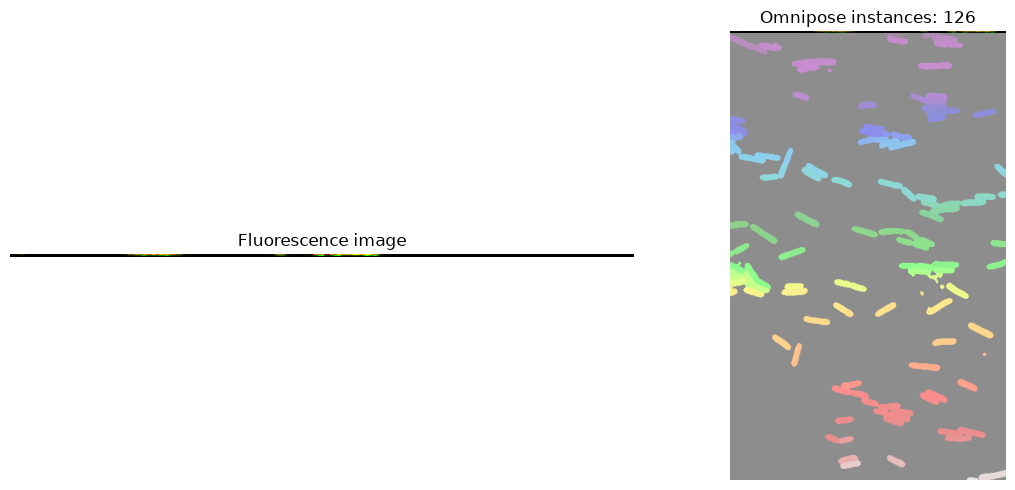

In [13]:
# Test on one image.
seg_image, seg_mask, seg_flows, seg_styles = segment_image_omnipose(sample_path)

print("Image:", seg_image.shape)
print("Mask:", seg_mask.shape, "instances:", int(seg_mask.max()))
def show_segmentation(image_rg, mask):
    rgb = np.stack([
        percentile_normalize_channel(image_rg[..., 0]),
        percentile_normalize_channel(image_rg[..., 1]),
        np.zeros(image_rg.shape[:2], dtype=np.float32)
    ], axis=-1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(rgb)
    plt.title("Fluorescence image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(rgb)
    plt.imshow(mask, alpha=0.45, cmap="nipy_spectral")
    plt.title(f"Omnipose instances: {int(mask.max())}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_segmentation(sample_rg, seg_mask)

## 6. Cell patch extraction

In [14]:
def extract_cell_patches(path, mask, margin=8, min_area=20, max_area=None):
    rg = read_tiff_rgb2(path)
    h, w = mask.shape
    patches = []
    instance_ids = []

    for instance_id in range(1, int(mask.max()) + 1):
        ys, xs = np.where(mask == instance_id)
        if len(xs) == 0:
            continue

        area = len(xs)
        if area < min_area:
            continue
        if max_area is not None and area > max_area:
            continue

        x0 = max(0, xs.min() - margin)
        x1 = min(w, xs.max() + margin + 1)
        y0 = max(0, ys.min() - margin)
        y1 = min(h, ys.max() + margin + 1)

        crop = rg[y0:y1, x0:x1]
        patches.append(crop)
        instance_ids.append(instance_id)

    return patches, instance_ids

## 7. Build a cell-level metadata table

In [15]:
df_meta['treatment'].unique()

<StringArray>
['CIP+ETOH', 'COAMOX+ETOH', 'GENT+ETOH', 'RIF+ETOH', 'WT+ETOH']
Length: 5, dtype: str

In [16]:
# Start very small on a laptop.
# Increase to 5, 10, 20 and finally None after validation

MAX_IMAGES_PER_TREATMENT = None

source_df = (
    df_meta
    .groupby("treatment", group_keys=False)
    .head(MAX_IMAGES_PER_TREATMENT)
    .reset_index(drop=True)
)

print(f"Images selected for segmentation: {len(source_df)}")

print("\nSelected images per treatment:")
print(source_df["treatment"].value_counts())

Images selected for segmentation: 1568

Selected images per treatment:
treatment
WT+ETOH        455
COAMOX+ETOH    350
CIP+ETOH       285
RIF+ETOH       279
GENT+ETOH      199
Name: count, dtype: int64


In [17]:
import warnings

warnings.filterwarnings('ignore')

In [18]:
cell_records = []
failed = []

for row in source_df.itertuples(index=False):
    try:
        _, mask, _, _ = segment_image_omnipose(row.path)
        patches, ids = extract_cell_patches(row.path, mask)

        for patch, instance_id in zip(patches, ids):
            cell_records.append({
                "image_path": row.path,
                "filename": row.filename,
                "date": row.date,
                "exp_id": row.exp_id,
                "species": row.species,
                "conc": row.conc,
                "proj": row.proj,
                "stage": row.stage,
                "acq": row.acq,
                "treatment": row.treatment,
                "pos": row.pos,
                "instance_id": int(instance_id),
                "patch": patch,
                "area": int((mask == instance_id).sum())
            })
    except Exception as e:
        failed.append((row.path, repr(e)))

cells_df = pd.DataFrame(cell_records)

print("Cell patches:", len(cells_df))
print("Failed images:", len(failed))

if failed:
    print("First failures:")
    for item in failed[:5]:
        print(item)

if cells_df.empty:
    raise RuntimeError(
        "No cell patches were extracted. Check Omnipose model/input channels and image data."
    )

KeyboardInterrupt: 

In [27]:
cells_df['treatment'].unique()

<StringArray>
['CIP+ETOH', 'WT+ETOH', 'COAMOX+ETOH', 'GENT+ETOH', 'RIF+ETOH']
Length: 5, dtype: str

## 8. Define the phenotype classes

In [29]:
print("Available treatments:")
print(sorted(cells_df["treatment"].dropna().astype(str).unique()))

Available treatments:
['CIP+ETOH', 'COAMOX+ETOH', 'GENT+ETOH', 'RIF+ETOH', 'WT+ETOH']


In [30]:
# ============================================================
# 5-CLASS TREATMENT MAPPING
# ============================================================

CLASS_MAP = {
    "WT+ETOH": 0,
    "CIP+ETOH": 1,
    "GENT+ETOH": 2,
    "RIF+ETOH": 3,
    "COAMOX+ETOH": 4
}

# Create numeric labels
cells_df["label"] = cells_df["treatment"].map(CLASS_MAP)

# Check for unexpected treatments
if cells_df["label"].isna().any():
    missing = cells_df.loc[
        cells_df["label"].isna(), "treatment"
    ].unique()

    raise ValueError(
        f"Treatments missing from CLASS_MAP: {missing}"
    )

cells_df["label"] = cells_df["label"].astype(int)

# Check that all 5 classes are present
if cells_df["label"].nunique() != 5:
    raise ValueError(
        f"Expected 5 treatment classes, "
        f"but found {cells_df['label'].nunique()}."
    )

# Check that every expected treatment exists
expected_treatments = set(CLASS_MAP.keys())
actual_treatments = set(cells_df["treatment"].unique())

missing_treatments = expected_treatments - actual_treatments

if missing_treatments:
    raise ValueError(
        f"Expected treatments not found in cells_df: {missing_treatments}"
    )

print("Class mapping:")
for treatment, label in CLASS_MAP.items():
    print(f"  {label}: {treatment}")

print("\nTreatment counts:")
print(cells_df["treatment"].value_counts())

print("\nLabel counts:")
print(cells_df["label"].value_counts().sort_index())

Class mapping:
  0: WT+ETOH
  1: CIP+ETOH
  2: GENT+ETOH
  3: RIF+ETOH
  4: COAMOX+ETOH

Treatment counts:
treatment
RIF+ETOH       744
CIP+ETOH       190
WT+ETOH         87
COAMOX+ETOH     73
GENT+ETOH       40
Name: count, dtype: int64

Label counts:
label
0     87
1    190
2     40
3    744
4     73
Name: count, dtype: int64


## 9. Group-aware train/validation/test split

In [31]:
image_groups = cells_df[["image_path", "label"]].drop_duplicates("image_path")

# 70% train, 15% validation, 15% test.
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_img_idx, temp_img_idx = next(
    gss1.split(image_groups, y=image_groups["label"], groups=image_groups["image_path"])
)

train_images = set(image_groups.iloc[train_img_idx]["image_path"])
temp_images = set(image_groups.iloc[temp_img_idx]["image_path"])

temp_df = image_groups[image_groups["image_path"].isin(temp_images)]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(
    gss2.split(temp_df, y=temp_df["label"], groups=temp_df["image_path"])
)

val_images = set(temp_df.iloc[val_idx]["image_path"])
test_images = set(temp_df.iloc[test_idx]["image_path"])

train_df = cells_df[cells_df["image_path"].isin(train_images)].reset_index(drop=True)
val_df = cells_df[cells_df["image_path"].isin(val_images)].reset_index(drop=True)
test_df = cells_df[cells_df["image_path"].isin(test_images)].reset_index(drop=True)

print("Images:", len(train_images), len(val_images), len(test_images))
print("Cells :", len(train_df), len(val_df), len(test_df))

assert train_images.isdisjoint(val_images)
assert train_images.isdisjoint(test_images)
assert val_images.isdisjoint(test_images)

print(pd.DataFrame({
    "split": ["train", "val", "test"],
    "images": [len(train_images), len(val_images), len(test_images)],
    "cells": [len(train_df), len(val_df), len(test_df)]
}))

Images: 7 1 2
Cells : 629 367 138
   split  images  cells
0  train       7    629
1    val       1    367
2   test       2    138


## 10. Dataset transforms

In [32]:
IMG_SIZE = 224

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
        max_pixel_value=1.0
    ),
    ToTensorV2()
])

eval_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
        max_pixel_value=1.0
    ),
    ToTensorV2()
])



In [33]:
class BacterialPatchDataset(Dataset):
    def __init__(self, frame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        patch = np.asarray(row["patch"])

        if patch.ndim != 3 or patch.shape[-1] != 2:
            raise ValueError(f"Expected HWC 2-channel patch, got {patch.shape}")

        r = percentile_normalize_channel(patch[..., 0])
        g = percentile_normalize_channel(patch[..., 1])
        rgb = np.stack([r, g, np.zeros_like(r)], axis=-1).astype(np.float32)

        if self.transform:
            out = self.transform(image=rgb)
            x = out["image"]
        else:
            x = torch.from_numpy(rgb).permute(2, 0, 1)

        y = torch.tensor(int(row["label"]), dtype=torch.long)
        return x, y


train_ds = BacterialPatchDataset(train_df, train_transform)
val_ds = BacterialPatchDataset(val_df, eval_transform)
test_ds = BacterialPatchDataset(test_df, eval_transform)

BATCH_SIZE = 2
NUM_WORKERS = 0

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)

x0, y0 = train_ds[0]
print("Sample tensor:", x0.shape, x0.dtype, "label:", y0.item())

Sample tensor: torch.Size([3, 224, 224]) torch.float32 label: 1


## 11. Swin-Tiny classifier

In [37]:
# ============================================================
# 11. Swin-Tiny 5-Class Classifier
# ============================================================

import math

NUM_CLASSES = 5

CLASS_NAMES = [
    "WT+ETOH",
    "CIP+ETOH",
    "GENT+ETOH",
    "RIF+ETOH",
    "COAMOX+ETOH"
]

# ------------------------------------------------------------
# Create Swin-Tiny backbone
# ------------------------------------------------------------

model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)

print(model)
print("\nModel device:", next(model.parameters()).device)
print("Number of classes:", NUM_CLASSES)


# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)


# ------------------------------------------------------------
# Learning-rate scheduler
# ------------------------------------------------------------

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=2
)

print("\nSwin-Tiny model ready.")
print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

2026-09-11 16:52:00,511	[INFO]     models\_builder.py            load...ained()	 line 219	Loading pretrained weights from Hugging Face hub (timm/swin_tiny_patch4_window7_224.ms_in1k)
2026-09-11 16:52:01,585	[INFO]     httpx\_client.py              _sen...quest()	 line 1025	HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
2026-09-11 16:52:01,832	[INFO]                                               	 line 1025	HTTP Request: HEAD https://huggingface.co/timm/swin_tiny_patch4_window7_224.ms_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2026-09-11 16:52:03,312	[INFO]                                               	 line 1025	HTTP Request: GET https://huggingface.co/api/models/timm/swin_tiny_patch4_window7_224.ms_in1k/xet-read-token/4cc3a7275b50b53a7bec45f32c236ebe64227cff "HTTP/1.1 200 OK"


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

2026-09-11 16:52:27,490	[INFO]     models\_hub.py                load...om_hf()	 line 244	[timm/swin_tiny_patch4_window7_224.ms_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


e:\Dissertations & Assignments\Dissertations\Research\aenv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Hi\.cache\huggingface\hub\models--timm--swin_tiny_patch4_window7_224.ms_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


2026-09-11 16:52:27,716	[INFO]     models\_builder.py            load...ained()	 line 284	Missing keys (head.fc.weight, head.fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.
SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path

In [38]:
# ============================================================
# 5-CLASS TRAINING / VALIDATION FUNCTION
# ============================================================

def run_epoch(model, loader, criterion, optimizer=None):

    training = optimizer is not None
    model.train(training)

    total_loss = 0.0

    all_labels = []
    all_preds = []
    all_probs = []

    context = (
        torch.enable_grad()
        if training
        else torch.no_grad()
    )

    with context:

        for inputs, labels in loader:

            inputs = inputs.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            if training:
                optimizer.zero_grad(
                    set_to_none=True
                )

            outputs = model(inputs)

            loss = criterion(
                outputs,
                labels
            )

            if training:
                loss.backward()
                optimizer.step()

            # Five-class probabilities
            probs = torch.softmax(
                outputs,
                dim=1
            )

            preds = outputs.argmax(
                dim=1
            )

            total_loss += (
                loss.item() *
                inputs.size(0)
            )

            all_labels.extend(
                labels.detach()
                .cpu()
                .numpy()
            )

            all_preds.extend(
                preds.detach()
                .cpu()
                .numpy()
            )

            all_probs.extend(
                probs.detach()
                .cpu()
                .numpy()
            )

    y_true = np.asarray(
        all_labels
    )

    y_pred = np.asarray(
        all_preds
    )

    y_prob = np.asarray(
        all_probs
    )

    avg_loss = (
        total_loss /
        max(1, len(y_true))
    )

    # --------------------------------------------------------
    # Overall metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    )

    # --------------------------------------------------------
    # Multiclass ROC-AUC
    # --------------------------------------------------------

    try:

        auc = roc_auc_score(
            y_true,
            y_prob,
            multi_class="ovr",
            average="weighted"
        )

    except ValueError:

        auc = np.nan

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

In [39]:
# ============================================================
# 12. Train Swin-Tiny
# ============================================================

EPOCHS = 2

history = []

for epoch in range(EPOCHS):

    train_metrics = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_metrics = run_epoch(
        model,
        val_loader,
        criterion
    )

    scheduler.step()

    history.append({
        "epoch": epoch + 1,

        "train_loss":
            train_metrics["loss"],

        "val_loss":
            val_metrics["loss"],

        "train_acc":
            train_metrics["accuracy"],

        "val_acc":
            val_metrics["accuracy"],

        "val_precision":
            val_metrics["precision"],

        "val_recall":
            val_metrics["recall"],

        "val_f1":
            val_metrics["f1"],

        "val_auc":
            val_metrics["auc"],
    })

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Val AUC: {val_metrics['auc']:.4f}"
    )

history_df = pd.DataFrame(history)

display(history_df)

Epoch 01/2 | Train Loss: 0.8510 | Val Loss: 0.1154 | Val Acc: 0.9755 | Val F1: 0.9876 | Val AUC: nan
Epoch 02/2 | Train Loss: 0.4835 | Val Loss: 0.0372 | Val Acc: 0.9891 | Val F1: 0.9945 | Val AUC: nan


,epoch,train_loss,val_loss,train_acc,val_acc,val_precision,val_recall,val_f1,val_auc
0,1,0.851004,0.115413,0.678855,0.975477,1.0,0.975477,0.987586,NaN
1,2,0.483521,0.037224,0.813990,0.989101,1.0,0.989101,0.994521,NaN


In [46]:
test_metrics = run_epoch(model, test_loader, criterion)

print(classification_report(
    test_metrics["y_true"],
    test_metrics["y_pred"],
    labels=np.arange(NUM_CLASSES),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

print({
    k: test_metrics[k]
    for k in ["loss", "accuracy", "precision", "recall", "f1", "auc"]
})

              precision    recall  f1-score   support

     WT+ETOH     0.0000    0.0000    0.0000         0
    CIP+ETOH     1.0000    0.6827    0.8114       104
   GENT+ETOH     0.0000    0.0000    0.0000         0
    RIF+ETOH     0.0000    0.0000    0.0000         0
 COAMOX+ETOH     1.0000    0.0588    0.1111        34

    accuracy                         0.5290       138
   macro avg     0.4000    0.1483    0.1845       138
weighted avg     1.0000    0.5290    0.6389       138

{'loss': 1.1630923649755076, 'accuracy': 0.5289855072463768, 'precision': 1.0, 'recall': 0.5289855072463768, 'f1': 0.6388865884518058, 'auc': nan}


## 14. Test-sample visualization

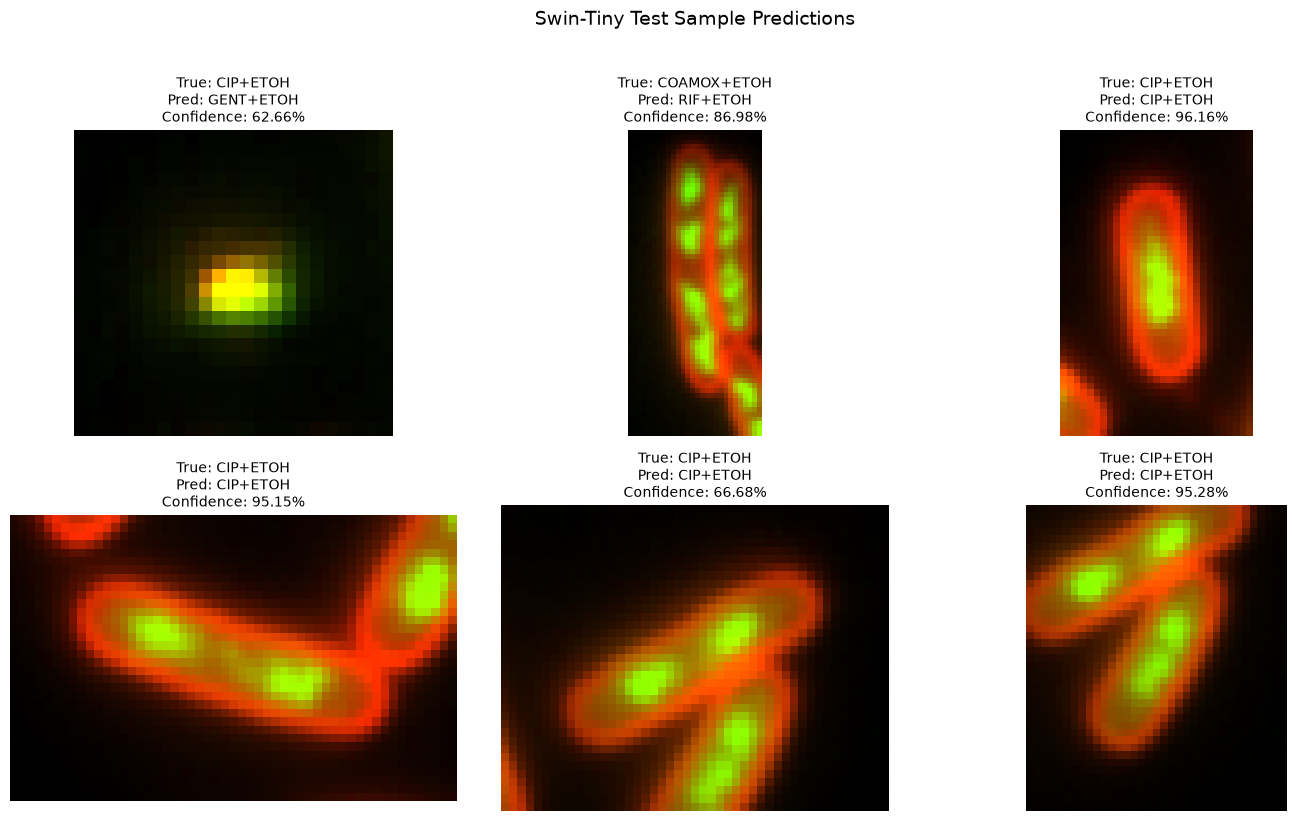

In [48]:
def visualize_test_samples(model, frame, n=6):
    n = min(n, len(frame))
    sample = frame.sample(n=n, random_state=SEED)

    model.eval()

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flat

    for ax, (_, row) in zip(axes, sample.iterrows()):

        ds_item = BacterialPatchDataset(
            pd.DataFrame([row]),
            eval_transform
        )

        x, y = ds_item[0]

        with torch.no_grad():
            logits = model(x.unsqueeze(0).to(device))
            probs = torch.softmax(logits, dim=1)[0]

            pred = int(logits.argmax(dim=1).item())
            confidence = float(probs[pred].item())

        true_label = CLASS_NAMES[int(y)]
        pred_label = CLASS_NAMES[pred]

        # Convert the 2-channel patch to RGB for display
        patch = row["patch"]

        rgb = np.stack([
            percentile_normalize_channel(patch[..., 0]),
            percentile_normalize_channel(patch[..., 1]),
            np.zeros(patch.shape[:2], dtype=np.float32)
        ], axis=-1)

        ax.imshow(rgb)

        ax.set_title(
            f"True: {true_label}\n"
            f"Pred: {pred_label}\n"
            f"Confidence: {confidence:.2%}",
            fontsize=10
        )

        ax.axis("off")

    # Hide unused axes if n < 6
    for ax in list(axes)[n:]:
        ax.axis("off")

    plt.suptitle(
        "Swin-Tiny Test Sample Predictions",
        fontsize=14,
        y=1.02
    )

    plt.tight_layout()
    plt.show()


visualize_test_samples(model, test_df, n=6)

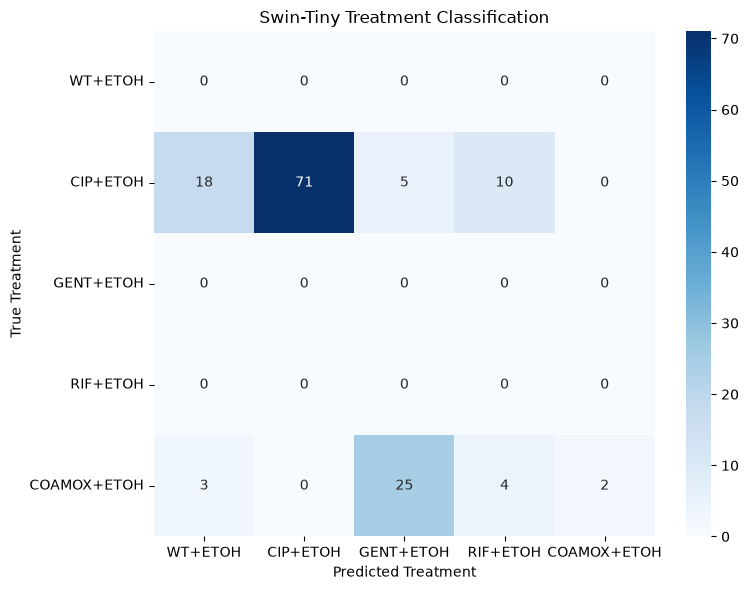

In [49]:
cm = confusion_matrix(
    test_metrics["y_true"],
    test_metrics["y_pred"],
    labels=np.arange(NUM_CLASSES)
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Treatment")
plt.ylabel("True Treatment")
plt.title("Swin-Tiny Treatment Classification")
plt.tight_layout()
plt.show()

## 15. Grad-CAM for Swin Transformer

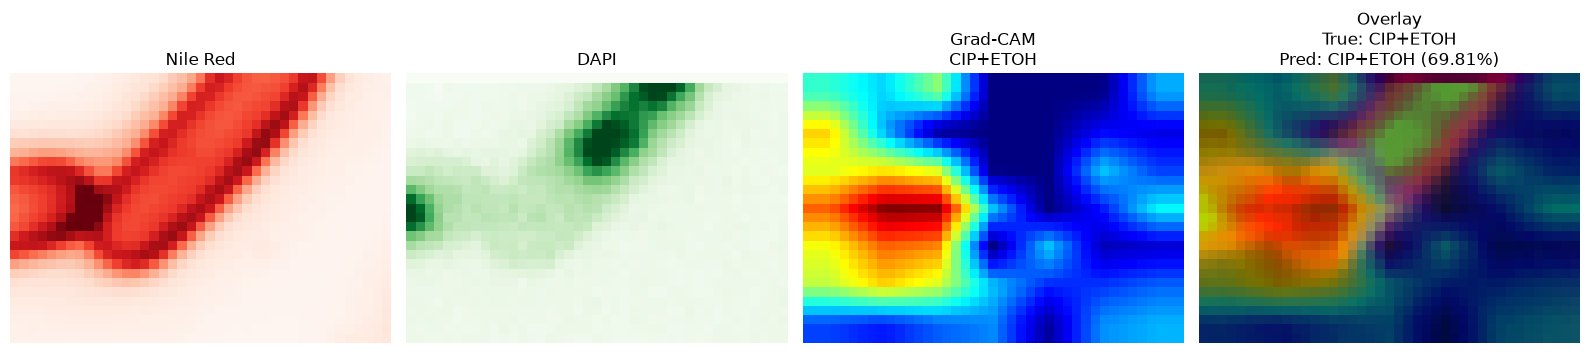

In [51]:
import math
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt


class SwinGradCAM:
    def __init__(self, model):
        self.model = model
        self.activations = None
        self.gradients = None

        # Direct timm SwinTransformer
        self.target_layer = (
            model.layers[-1]
            .blocks[-1]
            .norm1
        )

        self.fwd_handle = self.target_layer.register_forward_hook(
            self._save_activation
        )

        self.bwd_handle = self.target_layer.register_full_backward_hook(
            self._save_gradient
        )

    def _save_activation(self, module, inp, out):
        self.activations = out

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def remove(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

    @staticmethod
    def to_nchw(x):
        """
        Convert Swin feature tensor into [B, C, H, W].
        Handles both [B, H, W, C] and [B, L, C].
        """

        if x.ndim == 4:
            # Swin timm commonly uses [B, H, W, C]
            # Convert to [B, C, H, W]
            return x.permute(0, 3, 1, 2).contiguous()

        if x.ndim == 3:
            # [B, L, C]
            b, tokens, c = x.shape

            side = int(math.sqrt(tokens))

            if side * side != tokens:
                raise ValueError(
                    f"Cannot reshape {tokens} tokens into "
                    f"a square feature map. Shape: {tuple(x.shape)}"
                )

            return (
                x.transpose(1, 2)
                .reshape(b, c, side, side)
                .contiguous()
            )

        raise ValueError(
            f"Unexpected Swin feature shape: {tuple(x.shape)}"
        )

    def generate(self, x, target_class=None):

        self.model.zero_grad(set_to_none=True)

        logits = self.model(x)

        if target_class is None:
            target_class = int(
                logits.argmax(dim=1).item()
            )

        score = logits[0, target_class]

        score.backward()

        if self.activations is None:
            raise RuntimeError(
                "Grad-CAM activation was not captured."
            )

        if self.gradients is None:
            raise RuntimeError(
                "Grad-CAM gradients were not captured."
            )

        activations = self.to_nchw(
            self.activations
        )

        gradients = self.to_nchw(
            self.gradients
        )

        # Global average pooling of gradients
        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        # Weighted activation maps
        cam = (
            weights * activations
        ).sum(dim=1)

        # ReLU
        cam = F.relu(cam)

        cam = cam[0].detach().cpu().numpy()

        # Normalize
        if cam.max() > 0:
            cam = cam / cam.max()

        return cam, target_class


def visualize_swin_gradcam(model, row):

    model.eval()

    # Prepare dataset item
    ds_item = BacterialPatchDataset(
        pd.DataFrame([row]),
        eval_transform
    )

    x, y = ds_item[0]

    x = x.unsqueeze(0).to(device)

    # Generate Grad-CAM
    cam_engine = SwinGradCAM(model)

    try:
        cam, target_class = cam_engine.generate(x)
    finally:
        cam_engine.remove()

    # --------------------------------------------------
    # Original patch
    # --------------------------------------------------

    patch = row["patch"]

    rgb = np.stack([
        percentile_normalize_channel(
            patch[..., 0]
        ),
        percentile_normalize_channel(
            patch[..., 1]
        ),
        np.zeros(
            patch.shape[:2],
            dtype=np.float32
        )
    ], axis=-1)

    # Resize CAM to original patch size
    cam = cv2.resize(
        cam,
        (rgb.shape[1], rgb.shape[0]),
        interpolation=cv2.INTER_LINEAR
    )

    # Heatmap
    heat = cv2.applyColorMap(
        (cam * 255).astype(np.uint8),
        cv2.COLORMAP_JET
    )

    heat = cv2.cvtColor(
        heat,
        cv2.COLOR_BGR2RGB
    )

    # RGB image to uint8
    rgb_uint8 = (
        np.clip(rgb, 0, 1) * 255
    ).astype(np.uint8)

    # Overlay
    overlay = cv2.addWeighted(
        rgb_uint8,
        0.6,
        heat,
        0.4,
        0
    )

    # --------------------------------------------------
    # Class names
    # --------------------------------------------------

    true_class = int(y)

    true_name = (
        CLASS_NAMES[true_class]
        if true_class < len(CLASS_NAMES)
        else str(true_class)
    )

    pred_name = (
        CLASS_NAMES[target_class]
        if target_class < len(CLASS_NAMES)
        else str(target_class)
    )

    # Prediction confidence
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(
            logits,
            dim=1
        )[0]

        confidence = float(
            probs[target_class].item()
        )

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(16, 4)
    )

    axes[0].imshow(
        rgb[..., 0],
        cmap="Reds"
    )
    axes[0].set_title(
        "Nile Red"
    )

    axes[1].imshow(
        rgb[..., 1],
        cmap="Greens"
    )
    axes[1].set_title(
        "DAPI"
    )

    axes[2].imshow(
        heat
    )
    axes[2].set_title(
        f"Grad-CAM\n{pred_name}"
    )

    axes[3].imshow(
        overlay
    )
    axes[3].set_title(
        f"Overlay\n"
        f"True: {true_name}\n"
        f"Pred: {pred_name} ({confidence:.2%})"
    )

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


visualize_swin_gradcam(
    model,
    test_df.iloc[0]
)

## 16. Save the trained model and experiment metadata

In [52]:
OUTPUT_DIR = "./omnipose_swin_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "class_map": CLASS_MAP,
    "seed": SEED,
    "model_name": "swin_tiny_patch4_window7_224",
    "image_size": IMG_SIZE,
}, os.path.join(OUTPUT_DIR, "swin_tiny_phenotype_classifier.pt"))

history_df.to_csv(os.path.join(OUTPUT_DIR, "training_history.csv"), index=False)
test_df[["image_path", "filename", "treatment", "label", "instance_id", "area"]].to_csv(
    os.path.join(OUTPUT_DIR, "test_cell_metadata.csv"), index=False
)

print("Saved results to:", OUTPUT_DIR)

Saved results to: ./omnipose_swin_results
